## Add BioVariables to the **Final Dataset** and convert to **Annual** ##

In [1]:
import pandas as pd
import geopandas as gpd

import missingno

from sklearn.impute import KNNImputer
import sys

sys.path.insert(0, "../../../Modules")

from utils import *


enc = 'utf-8'
dec = 'greek8'

pd.options.display.max_columns = None
pd.options.display.max_rows = 20
#pd.options.display.float_format = lambda x: '%.6f' % x

In [2]:
NUTS0 = 'GR'
NUTS2 = 'Thrace'

In [3]:
years = range(2023, 2025)

In [4]:
datasets = []

for year in years:
    df = pd.read_csv(f"../../data/{NUTS2}/{NUTS0}_{NUTS2}_WNV_Dataset_GRID_{year}.csv", encoding=enc)
    print(f'Year: {year} | {df.shape}')
    datasets.append(df)

Year: 2023 | (39192, 102)
Year: 2024 | (22862, 102)


In [5]:
# dataset_monthly = pd.read_csv(f"../../data/{NUTS2}/{NUTS0}_{NUTS2}_WNV_Dataset_GRID_2016_2018.csv", encoding = enc)
dataset_monthly = pd.concat(datasets, ignore_index=True, axis = 0)
dataset_monthly

,cell_number,dt_placement,NUTS1_ID,NUTS1_NAME,NUTS2_ID,NUTS2_NAME,NUTS3_ID,NUTS3_NAME,LAU1_NAME,x,y,MOUNT_TYPE,URBN_TYPE,COAST_TYPE,year,month,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst_day_mean,lst_night_mean,lst_mean,lst_jan_day_mean,lst_feb_day_mean,lst_mar_day_mean,lst_apr_day_mean,lst_jan_night_mean,lst_feb_night_mean,lst_mar_night_mean,lst_apr_night_mean,lst_jan_mean,lst_feb_mean,lst_mar_mean,lst_apr_mean,rainfall_mean,acc_rainfall_1week,acc_rainfall_2week,acc_rainfall_month,acc_rainfall_jan,rainfall_acc,lst_min,lst_max,distance_to_coast,distance_to_river,slope_mean_1km,aspect_mean_200m,elevation_mean_1km,hillshade_mean_1km,fs_area_1km,flow_accu_200m,lc_prop1,lc_prop1_assessment,lc_prop2,lc_prop2_assessment,lc_prop3,lc_prop3_assessment,lc_type1,lc_type2,lc_type3,lc_type4,lc_type5,lw,qc,bio1,bio2,bio3,bio4,bio5,bio6,bio7,bio8,bio9,bio10,bio11,bio12,bio13,bio14,bio15,bio16,bio17,bio18,bio19,M_Y_LT15,M_Y15-64,M_Y_GE65,M_TOTAL,F_Y_LT15,F_Y15-64,F_Y_GE65,F_TOTAL,MIO_EUR,L_TOTAL,UNL_TOTAL
0,0,2023-01,EL5,βορεια ελλαδα,EL51,"ανατολικη μακεδονια, θρακη",EL514,δραμα,κατω νευροκοπιου,23.65882,41.33542,2,2,2,2023,1,0.123498,0.128873,0.040047,-0.128873,0.207506,0.037723,-0.102655,-0.037723,0.077778,0.072540,0.134168,0.072540,7.890741,1.496667,4.693704,7.890741,3.834286,11.336452,14.192143,1.496667,-1.748261,2.837097,2.906429,4.693704,1.043012,7.086774,8.549286,1.313090,10.404400,36.252339,40.705788,40.705788,40.705788,1.07,10.29,13573.304209,975.115126,7,273.211376,1038.457075,164.099283,0.0,4.925067,14,98.0,10,99.0,10,99.0,4,4,6,4,4,2,0,11.708333,16.916667,40.277778,691.000044,32.0,-10.0,42.0,12.833333,20.500000,20.666667,3.666667,489.0,118.0,1.0,105.251184,239.0,20.0,118.0,71.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,0,2023-02,EL5,βορεια ελλαδα,EL51,"ανατολικη μακεδονια, θρακη",EL514,δραμα,κατω νευροκοπιου,23.65882,41.33542,2,2,2,2023,2,0.172157,0.263083,-0.056745,-0.263083,0.171836,0.328531,-0.123536,-0.328531,0.033354,0.034344,0.072742,0.034344,3.834286,-1.748261,1.494348,7.890741,3.834286,11.336452,14.192143,1.496667,-1.748261,2.837097,2.906429,4.693704,1.043012,7.086774,8.549286,0.105860,0.106789,1.835538,9.508485,43.669873,2.964085,-10.17,14.37,13573.304209,975.115126,7,273.211376,1038.457075,164.099283,0.0,4.925067,14,98.0,10,99.0,10,99.0,4,4,6,4,4,2,0,11.708333,16.916667,40.277778,691.000044,32.0,-10.0,42.0,12.833333,20.500000,20.666667,3.666667,489.0,118.0,1.0,105.251184,239.0,20.0,118.0,71.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,0,2023-03,EL5,βορεια ελλαδα,EL51,"ανατολικη μακεδονια, θρακη",EL514,δραμα,κατω νευροκοπιου,23.65882,41.33542,2,2,2,2023,3,0.259614,0.085826,-0.202899,-0.085826,0.252877,0.057330,-0.240103,-0.057330,0.024621,0.029294,0.051733,0.029294,11.336452,2.837097,7.086774,7.890741,3.834286,11.336452,14.192143,1.496667,-1.748261,2.837097,2.906429,4.693704,1.043012,7.086774,8.549286,0.186350,0.215696,0.292328,4.540183,49.446721,5.776848,-1.97,17.77,13573.304209,975.115126,7,273.211376,1038.457075,164.099283,0.0,4.925067,14,98.0,10,99.0,10,99.0,4,4,6,4,4,2,0,11.708333,16.916667,40.277778,691.000044,32.0,-10.0,42.0,12.833333,20.500000,20.666667,3.666667,489.0,118.0,1.0,105.251184,239.0,20.0,118.0,71.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,0,2023-04,EL5,βορεια ελλαδα,EL51,"ανατολικη μακεδονια, θρακη",EL514,δραμα,κατω νευροκοπιου,23.65882,41.33542,2,2,2,2023,4,0.333333,-0.020283,-0.330561,0.020283,0.324107,-0.026384,-0.331857,0.026384,0.030544,0.076180,0.054970,0.076180,14.192143,2.906429,8.549286,7.890741,3.834286,11.336452,14.192143,1.496667,-1.748261,2.837097,2.906429,4.693704,1.043012,7.086774,8.549286,2.177803,28.463936,48.944922,65.334102,114.780823,65.334102,-0.57,17.83,13573.304209,975.115126,7,273.211376,1038.457075,164.099283,0.0,4.925067,14,98.0,10,99.0,10,99.0,4,4,6,4,4,2,0,11.708333,16.916667,40.277778,691.000044,32.0,-10.0,42.0,12.833333,20.500000,20.666667,3.666667,489.0,118.0,1.0,105.251184,239.0,20.0,118.0,71.0,NaN,NaN,

In [6]:
# dataset_monthly.cases.sum()

<Axes: >

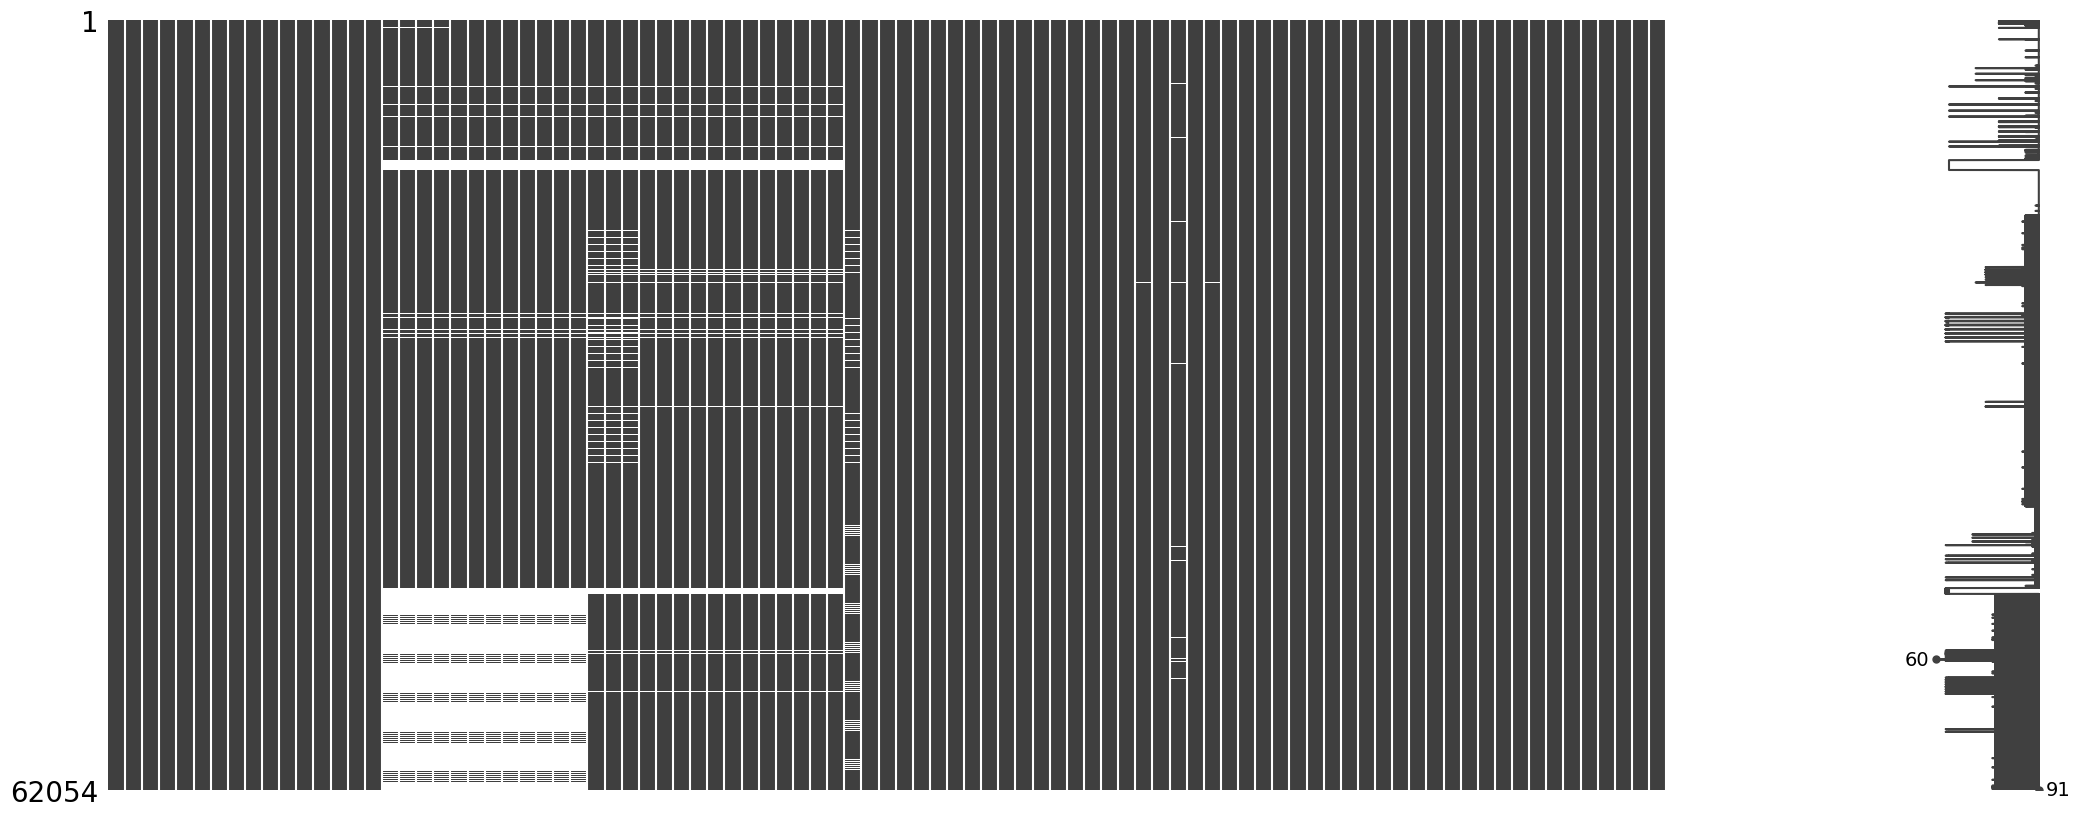

In [7]:
missingno.matrix(dataset_monthly)

In [8]:
missing = describe_dataframe(dataset_monthly, remove_zeros=True)
missing

,Column,Missing
16,ndvi,25.0604
17,ndmi,25.0604
18,ndwi,25.0604
19,ndbi,25.0604
20,ndvi_mean,24.8493
...,...,...
97,F_Y_GE65,100.0000
98,F_TOTAL,100.0000
99,MIO_EUR,100.0000
100,L_TOTAL,100.0000


In [9]:
all_columns = dataset_monthly.columns.to_list()

In [10]:
len(dataset_monthly.columns)

102

In [11]:
desired_order = ['dt_placement','NUTS2_ID','NUTS2_NAME','NUTS3_ID','NUTS3_NAME','LAU1_NAME', 'cell_number', 'x','y','month','year',
 'ndvi','ndmi','ndwi','ndbi','ndvi_mean','ndmi_mean','ndwi_mean','ndbi_mean','ndvi_std','ndmi_std','ndwi_std','ndbi_std',
 'lst_day_mean','lst_jan_day_mean','lst_feb_day_mean','lst_mar_day_mean','lst_apr_day_mean',
 'lst_night_mean','lst_jan_night_mean','lst_feb_night_mean','lst_mar_night_mean','lst_apr_night_mean',
 'lst_mean','lst_jan_mean','lst_feb_mean','lst_mar_mean','lst_apr_mean','lst_min','lst_max',
 'rainfall_mean','acc_rainfall_1week','acc_rainfall_2week','acc_rainfall_month','acc_rainfall_jan',
 'bio1','bio2','bio3','bio4','bio5','bio6','bio7','bio8','bio9','bio10','bio11','bio12','bio13','bio14','bio15','bio16','bio17','bio18','bio19',
 'distance_to_coast','distance_to_river','slope_mean_1km','aspect_mean_200m','elevation_mean_1km','hillshade_mean_1km','fs_area_1km','flow_accu_200m',
 'lc_prop1','lc_prop1_assessment','lc_prop2','lc_prop2_assessment','lc_prop3','lc_prop3_assessment','lc_type1','lc_type2','lc_type3','lc_type4','lc_type5','lw','qc',
 'M_Y_LT15','M_Y15-64','M_Y_GE65','M_TOTAL','F_Y_LT15','F_Y15-64','F_Y_GE65','F_TOTAL','MIO_EUR','L_TOTAL','UNL_TOTAL',
 'MOUNT_TYPE', 'URBN_TYPE', 'COAST_TYPE',
 ]

In [12]:
len(desired_order)

99

In [13]:
diff1 = set(desired_order) - set(all_columns)
diff2 = set(all_columns) - set(desired_order)

# Combine the differences
result = list(diff1.union(diff2))

In [14]:
result

['NUTS1_NAME', 'rainfall_acc', 'NUTS1_ID']

In [15]:
dataset_monthly = dataset_monthly[desired_order].copy()

In [16]:
dataset_monthly

,dt_placement,NUTS2_ID,NUTS2_NAME,NUTS3_ID,NUTS3_NAME,LAU1_NAME,cell_number,x,y,month,year,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst_day_mean,lst_jan_day_mean,lst_feb_day_mean,lst_mar_day_mean,lst_apr_day_mean,lst_night_mean,lst_jan_night_mean,lst_feb_night_mean,lst_mar_night_mean,lst_apr_night_mean,lst_mean,lst_jan_mean,lst_feb_mean,lst_mar_mean,lst_apr_mean,lst_min,lst_max,rainfall_mean,acc_rainfall_1week,acc_rainfall_2week,acc_rainfall_month,acc_rainfall_jan,bio1,bio2,bio3,bio4,bio5,bio6,bio7,bio8,bio9,bio10,bio11,bio12,bio13,bio14,bio15,bio16,bio17,bio18,bio19,distance_to_coast,distance_to_river,slope_mean_1km,aspect_mean_200m,elevation_mean_1km,hillshade_mean_1km,fs_area_1km,flow_accu_200m,lc_prop1,lc_prop1_assessment,lc_prop2,lc_prop2_assessment,lc_prop3,lc_prop3_assessment,lc_type1,lc_type2,lc_type3,lc_type4,lc_type5,lw,qc,M_Y_LT15,M_Y15-64,M_Y_GE65,M_TOTAL,F_Y_LT15,F_Y15-64,F_Y_GE65,F_TOTAL,MIO_EUR,L_TOTAL,UNL_TOTAL,MOUNT_TYPE,URBN_TYPE,COAST_TYPE
0,2023-01,EL51,"ανατολικη μακεδονια, θρακη",EL514,δραμα,κατω νευροκοπιου,0,23.65882,41.33542,1,2023,0.123498,0.128873,0.040047,-0.128873,0.207506,0.037723,-0.102655,-0.037723,0.077778,0.072540,0.134168,0.072540,7.890741,7.890741,3.834286,11.336452,14.192143,1.496667,1.496667,-1.748261,2.837097,2.906429,4.693704,4.693704,1.043012,7.086774,8.549286,1.07,10.29,1.313090,10.404400,36.252339,40.705788,40.705788,11.708333,16.916667,40.277778,691.000044,32.0,-10.0,42.0,12.833333,20.500000,20.666667,3.666667,489.0,118.0,1.0,105.251184,239.0,20.0,118.0,71.0,13573.304209,975.115126,7,273.211376,1038.457075,164.099283,0.0,4.925067,14,98.0,10,99.0,10,99.0,4,4,6,4,4,2,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2,2,2
1,2023-02,EL51,"ανατολικη μακεδονια, θρακη",EL514,δραμα,κατω νευροκοπιου,0,23.65882,41.33542,2,2023,0.172157,0.263083,-0.056745,-0.263083,0.171836,0.328531,-0.123536,-0.328531,0.033354,0.034344,0.072742,0.034344,3.834286,7.890741,3.834286,11.336452,14.192143,-1.748261,1.496667,-1.748261,2.837097,2.906429,1.494348,4.693704,1.043012,7.086774,8.549286,-10.17,14.37,0.105860,0.106789,1.835538,9.508485,43.669873,11.708333,16.916667,40.277778,691.000044,32.0,-10.0,42.0,12.833333,20.500000,20.666667,3.666667,489.0,118.0,1.0,105.251184,239.0,20.0,118.0,71.0,13573.304209,975.115126,7,273.211376,1038.457075,164.099283,0.0,4.925067,14,98.0,10,99.0,10,99.0,4,4,6,4,4,2,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2,2,2
2,2023-03,EL51,"ανατολικη μακεδονια, θρακη",EL514,δραμα,κατω νευροκοπιου,0,23.65882,41.33542,3,2023,0.259614,0.085826,-0.202899,-0.085826,0.252877,0.057330,-0.240103,-0.057330,0.024621,0.029294,0.051733,0.029294,11.336452,7.890741,3.834286,11.336452,14.192143,2.837097,1.496667,-1.748261,2.837097,2.906429,7.086774,4.693704,1.043012,7.086774,8.549286,-1.97,17.77,0.186350,0.215696,0.292328,4.540183,49.446721,11.708333,16.916667,40.277778,691.000044,32.0,-10.0,42.0,12.833333,20.500000,20.666667,3.666667,489.0,118.0,1.0,105.251184,239.0,20.0,118.0,71.0,13573.304209,975.115126,7,273.211376,1038.457075,164.099283,0.0,4.925067,14,98.0,10,99.0,10,99.0,4,4,6,4,4,2,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2,2,2
3,2023-04,EL51,"ανατολικη μακεδονια, θρακη",EL514,δραμα,κατω νευροκοπιου,0,23.65882,41.33542,4,2023,0.333333,-0.020283,-0.330561,0.020283,0.324107,-0.026384,-0.331857,0.026384,0.030544,0.076180,0.054970,0.076180,14.192143,7.890741,3.834286,11.336452,14.192143,2.906429,1.496667,-1.748261,2.837097,2.906429,8.549286,4.693704,1.043012,7.086774,8.549286,-0.57,17.83,2.177803,28.463936,48.944922,65.334102,114.780823,11.708333,16.916667,40.277778,691.000044,32.0,-10.0,42.0,12.833333,20.500000,20.666667,3.666667,489.0,118.0,1.0,105.251184,239.0,20.0,118.0,71.0,13573.304209,975.115126,7,273.211376,1038.457075,164.099283,0.0,4.925067,14,98.0,10,99.0,10,99.0,4,4,6,4,4,2,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2,2,2
4,2023-05,EL51,"ανατολικη μακεδονια, θρακη",EL514,δραμα,κατω νευροκοπιου,0,23.65882,41.33542,5,2023,0.65005

In [17]:
years = dataset_monthly.year.unique()
months =  dataset_monthly.month.unique()
cell_codes = dataset_monthly.cell_number.unique()

In [18]:
months = range(1,8)

In [19]:
data = []

for year in years[1:]:
    for month in months:
        print(f'Year: {year} | Month: {month}')
        for cell in cell_codes:
            df_regional = dataset_monthly.loc[(dataset_monthly['cell_number'] == cell)].copy()
            df_regional.reset_index(drop = True, inplace = True)

            df_prev_year = df_regional.loc[(df_regional['year'] == year-1)].copy()
            if month == 1:
                df_prev_month = df_regional.loc[(df_regional['year'] == year-1) & (df_regional['month'] == 12)].copy()
            else:
                df_prev_month = df_regional.loc[(df_regional['year'] == year) & (df_regional['month'] == month -1)].copy()

            df_curr_year = df_regional.loc[(df_regional['year'] == year) & (df_regional['month'] == month)].copy()
        
            data.append({'cell_number': cell,
                        'nuts2_id': df_curr_year.iloc[0]['NUTS2_ID'],
                        'nuts3_id': df_curr_year.iloc[0]['NUTS3_ID'],
                        'lau1': df_curr_year.iloc[0]['LAU1_NAME'], 
                        'year': year, 
                        'month': month,
                        'x' : df_curr_year.iloc[0]['x'],
                        'y': df_curr_year.iloc[0]['y'],
                        'ndvi': df_prev_month.iloc[0]['ndvi'],
                        'ndmi': df_prev_month.iloc[0]['ndmi'],
                        'ndwi': df_prev_month.iloc[0]['ndwi'],
                        'ndbi': df_prev_month.iloc[0]['ndbi'],
                        'ndvi_mean': df_prev_month.iloc[0]['ndvi_mean'],
                        'ndmi_mean': df_prev_month.iloc[0]['ndmi_mean'],
                        'ndwi_mean': df_prev_month.iloc[0]['ndwi_mean'],
                        'ndbi_mean': df_prev_month.iloc[0]['ndbi_mean'],
                        'ndvi_std': df_prev_month.iloc[0]['ndvi_std'],
                        'ndmi_std': df_prev_month.iloc[0]['ndmi_std'],
                        'ndwi_std': df_prev_month.iloc[0]['ndwi_std'],
                        'ndbi_std': df_prev_month.iloc[0]['ndbi_std'],

                        'lst_day_mean': df_prev_month.iloc[0]['lst_day_mean'],
                        'lst_jan_day_mean': df_curr_year.iloc[0]['lst_jan_day_mean'],
                        'lst_feb_day_mean': df_curr_year.iloc[0]['lst_feb_day_mean'],
                        'lst_mar_day_mean': df_curr_year.iloc[0]['lst_mar_day_mean'],
                        'lst_apr_day_mean': df_curr_year.iloc[0]['lst_apr_day_mean'],

                        'lst_night_mean': df_prev_month.iloc[0]['lst_night_mean'],
                        'lst_jan_night_mean': df_curr_year.iloc[0]['lst_jan_night_mean'],
                        'lst_feb_night_mean': df_curr_year.iloc[0]['lst_feb_night_mean'],
                        'lst_mar_night_mean': df_curr_year.iloc[0]['lst_mar_night_mean'],
                        'lst_apr_night_mean': df_curr_year.iloc[0]['lst_apr_night_mean'],

                        'lst_mean': df_prev_month.iloc[0]['lst_mean'],
                        'lst_jan_mean': df_curr_year.iloc[0]['lst_jan_mean'],
                        'lst_feb_mean': df_curr_year.iloc[0]['lst_feb_mean'],
                        'lst_mar_mean': df_curr_year.iloc[0]['lst_mar_mean'],
                        'lst_apr_mean': df_curr_year.iloc[0]['lst_apr_mean'],

                        'monthly_lst_min': df_prev_month.iloc[0]['lst_min'],
                        'monthly_lst_max': df_prev_month.iloc[0]['lst_max'],

                        'rainfall_mean': df_prev_month.iloc[0]['rainfall_mean'],
                        'acc_rainfall_1week': df_prev_month.iloc[0]['acc_rainfall_1week'],
                        'acc_rainfall_2week': df_prev_month.iloc[0]['acc_rainfall_2week'],
                        'acc_rainfall_month': df_prev_month.iloc[0]['acc_rainfall_month'],
                        'acc_rainfall_jan': df_curr_year.iloc[0]['acc_rainfall_jan'],

                        'bio1': df_prev_year.iloc[0]['bio1'],
                        'bio2': df_prev_year.iloc[0]['bio2'],
                        'bio3': df_prev_year.iloc[0]['bio3'],
                        'bio4': df_prev_year.iloc[0]['bio4'],
                        'bio5': df_prev_year.iloc[0]['bio5'],
                        'bio6': df_prev_year.iloc[0]['bio6'],
                        'bio7': df_prev_year.iloc[0]['bio7'],
                        'bio8': df_prev_year.iloc[0]['bio8'],
                        'bio9': df_prev_year.iloc[0]['bio9'],
                        'bio10': df_prev_year.iloc[0]['bio10'],
                        'bio11': df_prev_year.iloc[0]['bio11'],
                        'bio12': df_prev_year.iloc[0]['bio12'],
                        'bio13': df_prev_year.iloc[0]['bio13'],
                        'bio14': df_prev_year.iloc[0]['bio14'],
                        'bio15': df_prev_year.iloc[0]['bio15'],
                        'bio16': df_prev_year.iloc[0]['bio16'],
                        'bio17': df_prev_year.iloc[0]['bio17'],
                        'bio18': df_prev_year.iloc[0]['bio18'],
                        'bio19': df_prev_year.iloc[0]['bio19'],

                        'lc_prop1': df_curr_year.iloc[0]['lc_prop1'],
                        'lc_prop2': df_curr_year.iloc[0]['lc_prop2'],
                        'lc_prop3': df_curr_year.iloc[0]['lc_prop3'],
                        'lc_type1': df_curr_year.iloc[0]['lc_type1'],
                        'lc_type2': df_curr_year.iloc[0]['lc_type2'],
                        'lc_type3': df_curr_year.iloc[0]['lc_type3'],
                        'lc_type4': df_curr_year.iloc[0]['lc_type4'],
                        'lc_type5': df_curr_year.iloc[0]['lc_type5'],

                        'distance_to_coast': df_curr_year.iloc[0]['distance_to_coast'],
                        'distance_to_river': df_curr_year.iloc[0]['distance_to_river'],
                        'slope_mean_1km': df_curr_year.iloc[0]['slope_mean_1km'],
                        'aspect_mean_200m': df_curr_year.iloc[0]['aspect_mean_200m'],
                        'elevation_mean_1km': df_curr_year.iloc[0]['elevation_mean_1km'],
                        'hillshade_mean_1km': df_curr_year.iloc[0]['hillshade_mean_1km'],
                        'fs_area_1km': df_curr_year.iloc[0]['fs_area_1km'],
                        'flow_accu_200m': df_curr_year.iloc[0]['flow_accu_200m'],

                        'males_lt15': df_prev_year.iloc[0]['M_Y_LT15'],
                        'males_15t64': df_prev_year.iloc[0]['M_Y15-64'],
                        'males_gt65': df_prev_year.iloc[0]['M_Y_GE65'],
                        'males_total': df_prev_year.iloc[0]['M_TOTAL'],
                        'females_lt15': df_prev_year.iloc[0]['F_Y_LT15'],
                        'females_15t64': df_prev_year.iloc[0]['F_Y15-64'],
                        'females_gt65': df_prev_year.iloc[0]['F_Y_GE65'],
                        'females_total': df_prev_year.iloc[0]['F_TOTAL'],
                        'mio_eur': df_prev_year.iloc[0]['MIO_EUR'],
                        'l_total': df_prev_year.iloc[0]['L_TOTAL'],
                        'unl_total': df_prev_year.iloc[0]['UNL_TOTAL'],

                        'mount_type': df_prev_month.iloc[0]['MOUNT_TYPE'],
                        'urbn_type': df_prev_month.iloc[0]['URBN_TYPE'],
                        'coast_type': df_prev_month.iloc[0]['COAST_TYPE'],
                    
                        # 'cases': df_curr_year.iloc[0]['cases'],
                        })
        
dataset_operational = pd.DataFrame(data)       

Year: 2024 | Month: 1
Year: 2024 | Month: 2
Year: 2024 | Month: 3
Year: 2024 | Month: 4
Year: 2024 | Month: 5
Year: 2024 | Month: 6
Year: 2024 | Month: 7


In [20]:
dataset_monthly[(dataset_monthly['cell_number'] == 0) & (dataset_monthly['year'] == 2023)].drop(columns=['NUTS2_ID','NUTS2_NAME','NUTS3_ID','LAU1_NAME'])

,dt_placement,NUTS3_NAME,cell_number,x,y,month,year,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst_day_mean,lst_jan_day_mean,lst_feb_day_mean,lst_mar_day_mean,lst_apr_day_mean,lst_night_mean,lst_jan_night_mean,lst_feb_night_mean,lst_mar_night_mean,lst_apr_night_mean,lst_mean,lst_jan_mean,lst_feb_mean,lst_mar_mean,lst_apr_mean,lst_min,lst_max,rainfall_mean,acc_rainfall_1week,acc_rainfall_2week,acc_rainfall_month,acc_rainfall_jan,bio1,bio2,bio3,bio4,bio5,bio6,bio7,bio8,bio9,bio10,bio11,bio12,bio13,bio14,bio15,bio16,bio17,bio18,bio19,distance_to_coast,distance_to_river,slope_mean_1km,aspect_mean_200m,elevation_mean_1km,hillshade_mean_1km,fs_area_1km,flow_accu_200m,lc_prop1,lc_prop1_assessment,lc_prop2,lc_prop2_assessment,lc_prop3,lc_prop3_assessment,lc_type1,lc_type2,lc_type3,lc_type4,lc_type5,lw,qc,M_Y_LT15,M_Y15-64,M_Y_GE65,M_TOTAL,F_Y_LT15,F_Y15-64,F_Y_GE65,F_TOTAL,MIO_EUR,L_TOTAL,UNL_TOTAL,MOUNT_TYPE,URBN_TYPE,COAST_TYPE
0,2023-01,δραμα,0,23.65882,41.33542,1,2023,0.123498,0.128873,0.040047,-0.128873,0.207506,0.037723,-0.102655,-0.037723,0.077778,0.072540,0.134168,0.072540,7.890741,7.890741,3.834286,11.336452,14.192143,1.496667,1.496667,-1.748261,2.837097,2.906429,4.693704,4.693704,1.043012,7.086774,8.549286,1.07,10.29,1.313090,10.404400,36.252339,40.705788,40.705788,11.708333,16.916667,40.277778,691.000044,32.0,-10.0,42.0,12.833333,20.5,20.666667,3.666667,489.0,118.0,1.0,105.251184,239.0,20.0,118.0,71.0,13573.304209,975.115126,7,273.211376,1038.457075,164.099283,0.0,4.925067,14,98.0,10,99.0,10,99.0,4,4,6,4,4,2,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2,2,2
1,2023-02,δραμα,0,23.65882,41.33542,2,2023,0.172157,0.263083,-0.056745,-0.263083,0.171836,0.328531,-0.123536,-0.328531,0.033354,0.034344,0.072742,0.034344,3.834286,7.890741,3.834286,11.336452,14.192143,-1.748261,1.496667,-1.748261,2.837097,2.906429,1.494348,4.693704,1.043012,7.086774,8.549286,-10.17,14.37,0.105860,0.106789,1.835538,9.508485,43.669873,11.708333,16.916667,40.277778,691.000044,32.0,-10.0,42.0,12.833333,20.5,20.666667,3.666667,489.0,118.0,1.0,105.251184,239.0,20.0,118.0,71.0,13573.304209,975.115126,7,273.211376,1038.457075,164.099283,0.0,4.925067,14,98.0,10,99.0,10,99.0,4,4,6,4,4,2,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2,2,2
2,2023-03,δραμα,0,23.65882,41.33542,3,2023,0.259614,0.085826,-0.202899,-0.085826,0.252877,0.057330,-0.240103,-0.057330,0.024621,0.029294,0.051733,0.029294,11.336452,7.890741,3.834286,11.336452,14.192143,2.837097,1.496667,-1.748261,2.837097,2.906429,7.086774,4.693704,1.043012,7.086774,8.549286,-1.97,17.77,0.186350,0.215696,0.292328,4.540183,49.446721,11.708333,16.916667,40.277778,691.000044,32.0,-10.0,42.0,12.833333,20.5,20.666667,3.666667,489.0,118.0,1.0,105.251184,239.0,20.0,118.0,71.0,13573.304209,975.115126,7,273.211376,1038.457075,164.099283,0.0,4.925067,14,98.0,10,99.0,10,99.0,4,4,6,4,4,2,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2,2,2
3,2023-04,δραμα,0,23.65882,41.33542,4,2023,0.333333,-0.020283,-0.330561,0.020283,0.324107,-0.026384,-0.331857,0.026384,0.030544,0.076180,0.054970,0.076180,14.192143,7.890741,3.834286,11.336452,14.192143,2.906429,1.496667,-1.748261,2.837097,2.906429,8.549286,4.693704,1.043012,7.086774,8.549286,-0.57,17.83,2.177803,28.463936,48.944922,65.334102,114.780823,11.708333,16.916667,40.277778,691.000044,32.0,-10.0,42.0,12.833333,20.5,20.666667,3.666667,489.0,118.0,1.0,105.251184,239.0,20.0,118.0,71.0,13573.304209,975.115126,7,273.211376,1038.457075,164.099283,0.0,4.925067,14,98.0,10,99.0,10,99.0,4,4,6,4,4,2,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2,2,2
4,2023-05,δραμα,0,23.65882,41.33542,5,2023,0.650051,0.327332,-0.490809,-0.327332,0.565658,0.258176,-0.432905,-0.258176,0.069263,0.072321,0.044636,0.072321,18.451935,7.890741,3.834286,11.336452,14.192143,6.447419,1.496667,-1.748261,2.837097,2.906429,12.449677,4.693704,1.043012,7.086774,8.549286,3.17,23.05,2.873775,25.029206,27.450337,59.685160,203.867839,11.708333,16.916667,40.277778,691.0000

In [21]:
dataset_operational[(dataset_operational['cell_number'] == 0) & (dataset_operational['year'] == 2024)]

,cell_number,nuts2_id,nuts3_id,lau1,year,month,x,y,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst_day_mean,lst_jan_day_mean,lst_feb_day_mean,lst_mar_day_mean,lst_apr_day_mean,lst_night_mean,lst_jan_night_mean,lst_feb_night_mean,lst_mar_night_mean,lst_apr_night_mean,lst_mean,lst_jan_mean,lst_feb_mean,lst_mar_mean,lst_apr_mean,monthly_lst_min,monthly_lst_max,rainfall_mean,acc_rainfall_1week,acc_rainfall_2week,acc_rainfall_month,acc_rainfall_jan,bio1,bio2,bio3,bio4,bio5,bio6,bio7,bio8,bio9,bio10,bio11,bio12,bio13,bio14,bio15,bio16,bio17,bio18,bio19,lc_prop1,lc_prop2,lc_prop3,lc_type1,lc_type2,lc_type3,lc_type4,lc_type5,distance_to_coast,distance_to_river,slope_mean_1km,aspect_mean_200m,elevation_mean_1km,hillshade_mean_1km,fs_area_1km,flow_accu_200m,males_lt15,males_15t64,males_gt65,males_total,females_lt15,females_15t64,females_gt65,females_total,mio_eur,l_total,unl_total,mount_type,urbn_type,coast_type
0,0,EL51,EL514,κατω νευροκοπιου,2024,1,23.65882,41.33542,0.121936,0.218493,0.027881,-0.218493,0.201648,0.146335,-0.119347,-0.146335,0.082059,0.091103,0.115234,0.091103,5.778667,2.144194,8.146552,11.033226,20.928621,1.690667,-1.550645,1.583103,1.028065,7.520345,3.734667,0.296774,4.864828,6.030645,14.224483,-3.89,10.17,0.997899,0.000000,0.105730,25.932531,41.533057,11.708333,16.916667,40.277778,691.000044,32.0,-10.0,42.0,12.833333,20.5,20.666667,3.666667,489.0,118.0,1.0,105.251184,239.0,20.0,118.0,71.0,14,10,10,4,4,6,4,4,13573.304209,975.115126,7,273.211376,1038.457075,164.099283,0.0,4.925067,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2,2,2
3266,0,EL51,EL514,κατω νευροκοπιου,2024,2,23.65882,41.33542,0.158323,0.215487,-0.000889,-0.215487,0.199381,0.139230,-0.122525,-0.139230,0.065784,0.085729,0.100493,0.085729,2.144194,2.144194,8.146552,11.033226,20.928621,-1.550645,-1.550645,1.583103,1.028065,7.520345,0.296774,0.296774,4.864828,6.030645,14.224483,-7.19,7.43,1.339776,0.272635,13.341247,41.531526,53.797667,11.708333,16.916667,40.277778,691.000044,32.0,-10.0,42.0,12.833333,20.5,20.666667,3.666667,489.0,118.0,1.0,105.251184,239.0,20.0,118.0,71.0,14,10,10,4,4,6,4,4,13573.304209,975.115126,7,273.211376,1038.457075,164.099283,0.0,4.925067,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2,2,2
6532,0,EL51,EL514,κατω νευροκοπιου,2024,3,23.65882,41.33542,0.216415,0.135713,-0.141988,-0.135713,0.201202,0.109560,-0.165407,-0.109560,0.044973,0.057022,0.058943,0.057022,8.146552,2.144194,8.146552,11.033226,20.928621,1.583103,-1.550645,1.583103,1.028065,7.520345,4.864828,0.296774,4.864828,6.030645,14.224483,-4.87,12.09,0.422918,4.489590,4.490472,12.264610,92.783077,11.708333,16.916667,40.277778,691.000044,32.0,-10.0,42.0,12.833333,20.5,20.666667,3.666667,489.0,118.0,1.0,105.251184,239.0,20.0,118.0,71.0,14,10,10,4,4,6,4,4,13573.304209,975.115126,7,273.211376,1038.457075,164.099283,0.0,4.925067,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2,2,2
9798,0,EL51,EL514,κατω νευροκοπιου,2024,4,23.65882,41.33542,0.288020,0.020938,-0.269782,-0.020938,0.271464,-0.014406,-0.261725,0.014406,0.040399,0.034564,0.050305,0.034564,11.033226,2.144194,8.146552,11.033226,20.928621,1.028065,-1.550645,1.583103,1.028065,7.520345,6.030645,0.296774,4.864828,6.030645,14.224483,-2.25,22.23,1.257594,11.542164,12.303511,38.158617,137.577378,11.708333,16.916667,40.277778,691.000044,32.0,-10.0,42.0,12.833333,20.5,20.666667,3.666667,489.0,118.0,1.0,105.251184,239.0,20.0,118.0,71.0,14,10,10,4,4,6,4,4,13573.304209,975.115126,7,273.211376,1038.457075,164.099283,0.0,4.925067,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2,2,2
13064,0,EL51,EL514,κατω νευροκοπιου,2024,5,23.65882,41.33542,0.415067,0.090004,-0.372324,-0.090004,0.404440,0.054322,-0.369121,-0.054322,0.032283,0.029452,0.039463,0.029452,20.928621,2.144194,8.146552,11.033226,20.928621,7.520345,-1.550645,1.583103,1.028065,7.520345,14.224483,0.296774,4.864828,6.030645,14.224483,1.49,24.25,1.493143,3.880080,44.668190,44.794301,193.701673,11.708333,16.916667,40.277778,691.000044,32.0,-10

<Axes: >

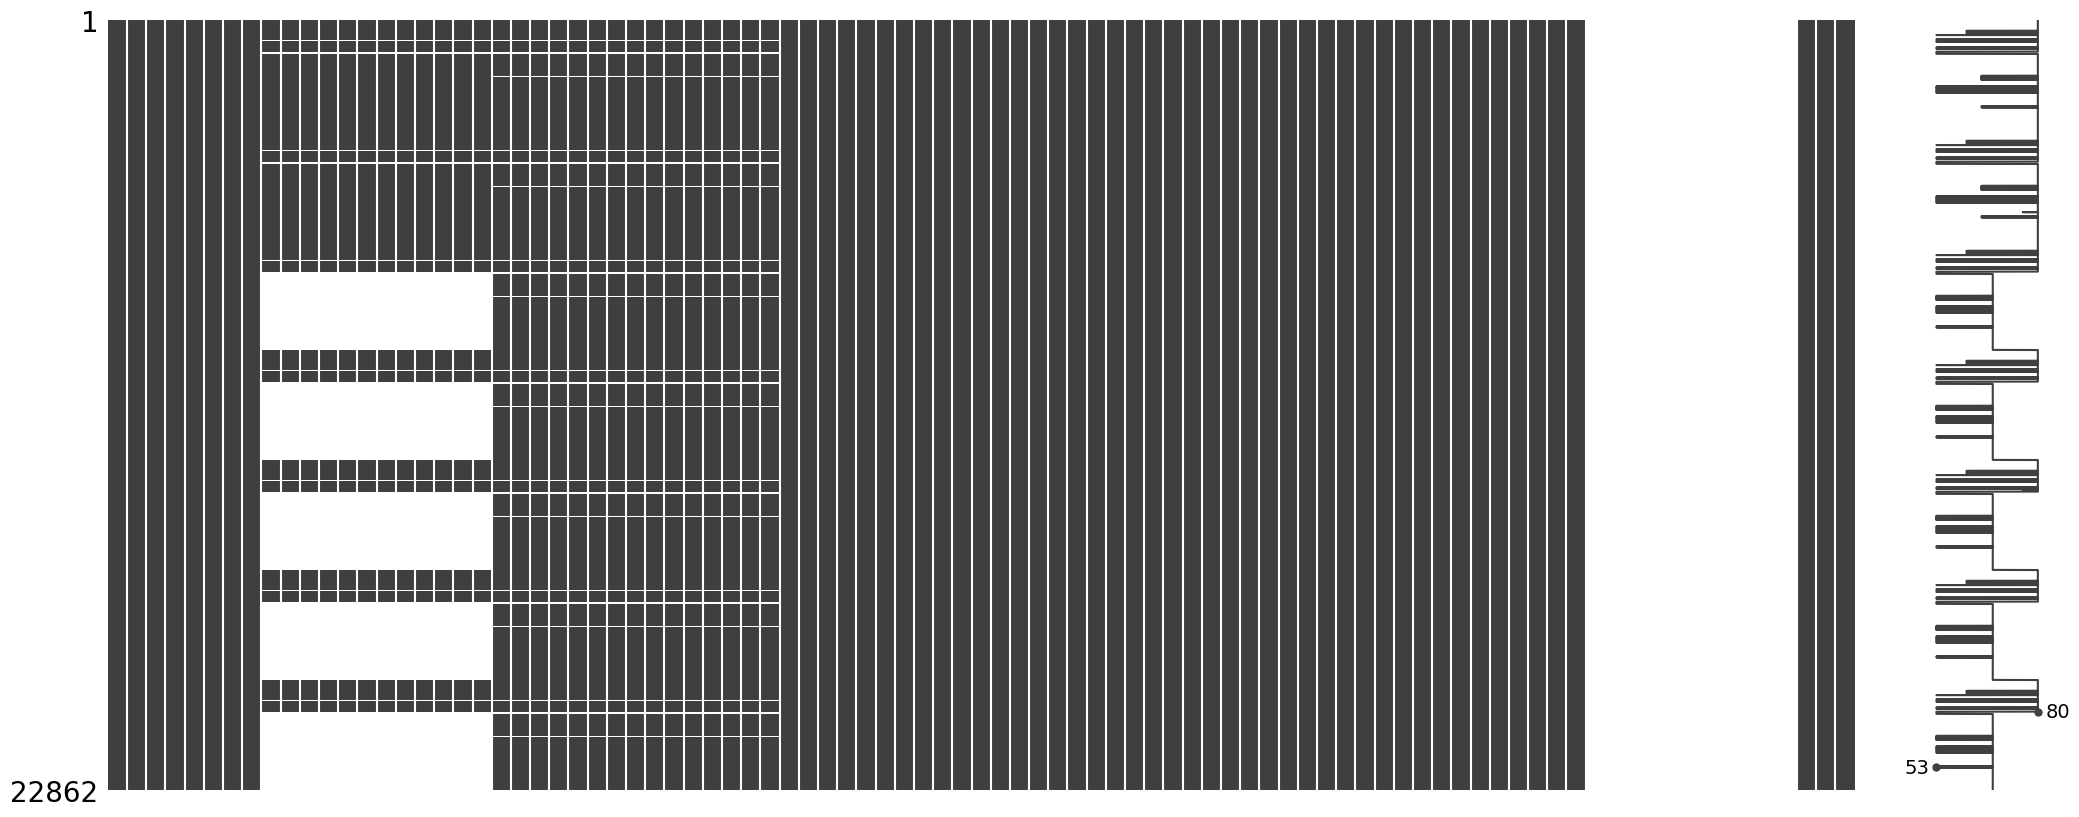

In [22]:
missingno.matrix(dataset_operational)

In [23]:
missing = describe_dataframe(dataset_operational, remove_zeros=True)
missing

,Column,Missing
8,ndvi,52.0777
9,ndmi,52.0777
10,ndwi,52.0777
11,ndbi,52.0777
12,ndvi_mean,51.9727
...,...,...
83,females_gt65,100.0000
84,females_total,100.0000
85,mio_eur,100.0000
86,l_total,100.0000


In [24]:
# dataset_monthly.cases.sum()

In [25]:
# dataset_operational.cases.sum()

In [26]:
years = dataset_operational.year.unique().tolist()

In [27]:
years

[2024]

In [28]:
for item in years:
    dataset_operational[dataset_operational.year == item].to_csv(f"../../data/{NUTS2}/{NUTS0}_{NUTS2}_WNV_Dataset_GRID_OP_{item}.csv", encoding = enc, index = False)